In [12]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import defaultdict
import heapq

def dyna_q_plus(n_planning=50, kappa=1e-3, total_steps_limit=3000):
    env = gym.make("Taxi-v3")
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    # Q-table and Model
    Q = np.zeros((n_states, n_actions))
    # Model stores (reward, next_state, terminated)
    model = {} 
    
    # Dyna-Q+ specific: track time since last real visit for ALL (s,a)
    # Sutton & Barto Ch 8.3: Exploration bonus is based on time since last visit
    tau = np.zeros((n_states, n_actions))
    
    # We need to know all possible actions to allow planning for actions 
    # that haven't been tried yet (a key feature of Dyna-Q+)
    all_actions = list(range(n_actions))
    observed_states = set()

    state, _ = env.reset()
    
    # Tracking for visualization
    history = {"step": [], "reward": []}
    cumulative_reward = 0
    
    alpha = 0.1
    gamma = 0.95
    epsilon = 0.1

    for t in range(total_steps_limit):
        observed_states.add(state)
        
        # 1. Action Selection (epsilon-greedy)
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        # 2. Execute Action with Dynamic Environment Change
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        # --- DYNAMIC CHANGE LOGIC ---
        # Requirement: modify environment structure after 1000 steps
        if t > 1000:
            # Simulate a 'Bridge Closure' or 'Wrong Destination'
            # If the agent tries to drop off at a specific successful location, 
            # we suddenly make it highly negative to see if it adapts.
            if reward == 20: 
                reward = -10 # The 'Old' optimal way is now a penalty
        # -----------------------------

        done = terminated or truncated
        cumulative_reward += reward
        
        # 3. Direct RL Update
        best_next_q = np.max(Q[next_state])
        target = reward + (gamma * best_next_q if not done else 0)
        Q[state, action] += alpha * (target - Q[state, action])

        # 4. Model Update & Tau Reset
        model[(state, action)] = (reward, next_state, done)
        
        # Update tau: increment everyone, reset the one we just took
        tau += 1
        tau[state, action] = 0

        # 5. Planning
        for _ in range(n_planning):
            # Dyna-Q+ improvement: Sample from ANY state ever seen
            s_sim = random.choice(list(observed_states))
            a_sim = random.choice(all_actions)
            
            if (s_sim, a_sim) in model:
                r_sim, ns_sim, d_sim = model[(s_sim, a_sim)]
            else:
                # Sutton & Barto: Actions never tried before are assumed 
                # to lead back to the same state with zero reward
                r_sim, ns_sim, d_sim = 0, s_sim, False
            
            # Apply Exploration Bonus: R + kappa * sqrt(tau)
            bonus_reward = r_sim + kappa * np.sqrt(tau[s_sim, a_sim])
            
            target_sim = bonus_reward + (gamma * np.max(Q[ns_sim]) if not d_sim else 0)
            Q[s_sim, a_sim] += alpha * (target_sim - Q[s_sim, a_sim])

        # Transition
        if done:
            state, _ = env.reset()
        else:
            state = next_state
            
        history["step"].append(t)
        history["reward"].append(cumulative_reward)

    env.close()
    return history

def prioritized_sweeping(n_planning=10, theta=1e-3, num_episodes=200):
    env = gym.make("Taxi-v3")
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    Q = np.zeros((n_states, n_actions))
    model = {} # (s, a) -> (r, s')
    # Predecessors: s' -> set of (s, a) that lead to it
    predecessors = defaultdict(set)
    
    alpha = 0.1
    gamma = 0.95
    epsilon = 0.1
    priority_queue = []
    
    history = {"step": [], "reward": []}
    total_steps = 0
    cumulative_reward = 0

    while total_steps < 3000:
        state, _ = env.reset()
        done = False
        
        while not done:
            # 1. Action Selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
                
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            cumulative_reward += reward
            total_steps += 1
            
            # 2. Model Learning & Predecessor Tracking
            model[(state, action)] = (reward, next_state)
            predecessors[next_state].add((state, action))
            
            # 3. Calculate Priority for the current transition
            # P = |r + gamma * max_a Q(s', a) - Q(s, a)|
            priority = abs(reward + gamma * np.max(Q[next_state]) - Q[state, action])
            
            if priority > theta:
                # heapq is a min-heap, so we use negative priority for a max-heap
                heapq.heappush(priority_queue, (-priority, state, action))
            
            # 4. Planning (Prioritized)
            count = 0
            while priority_queue and count < n_planning:
                _, s_sim, a_sim = heapq.heappop(priority_queue)
                r_sim, ns_sim = model[(s_sim, a_sim)]
                
                # Update Q-value
                target = r_sim + gamma * np.max(Q[ns_sim])
                Q[s_sim, a_sim] += alpha * (target - Q[s_sim, a_sim])
                
                # Check all predecessors of s_sim
                for s_pre, a_pre in predecessors[s_sim]:
                    r_pre, _ = model[(s_pre, a_pre)]
                    p_pre = abs(r_pre + gamma * np.max(Q[s_sim]) - Q[s_pre, a_pre])
                    
                    if p_pre > theta:
                        heapq.heappush(priority_queue, (-p_pre, s_pre, a_pre))
                
                count += 1
            
            state = next_state
            
        history["step"].append(total_steps)
        history["reward"].append(cumulative_reward)
        
    env.close()
    return history

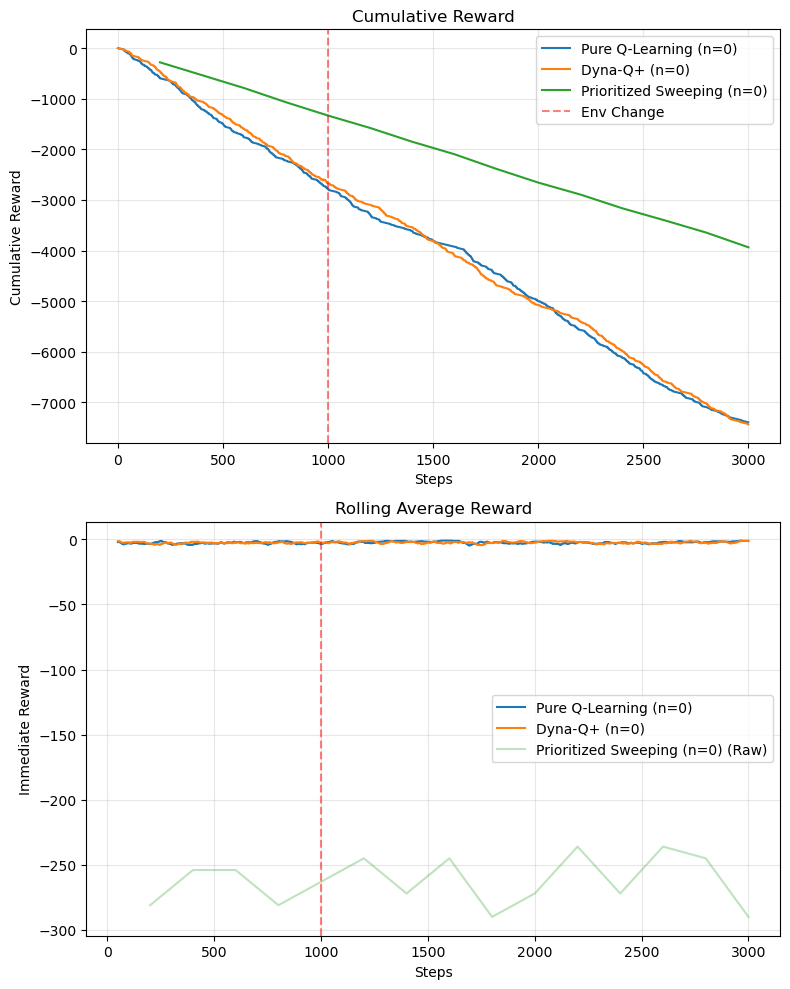

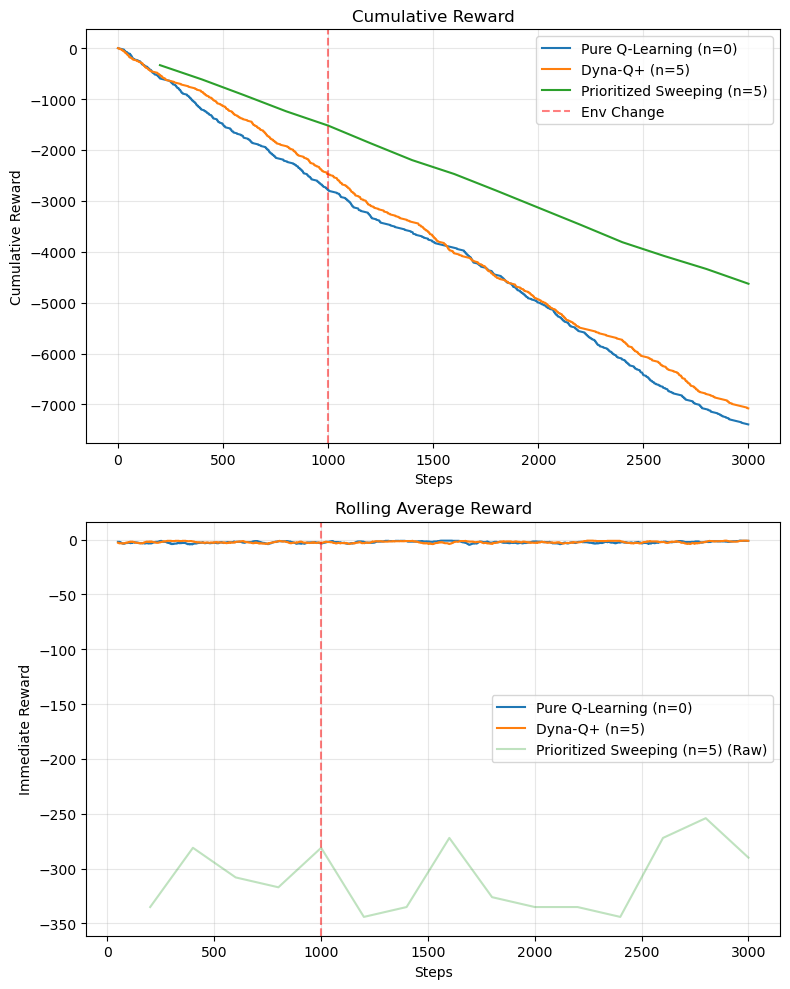

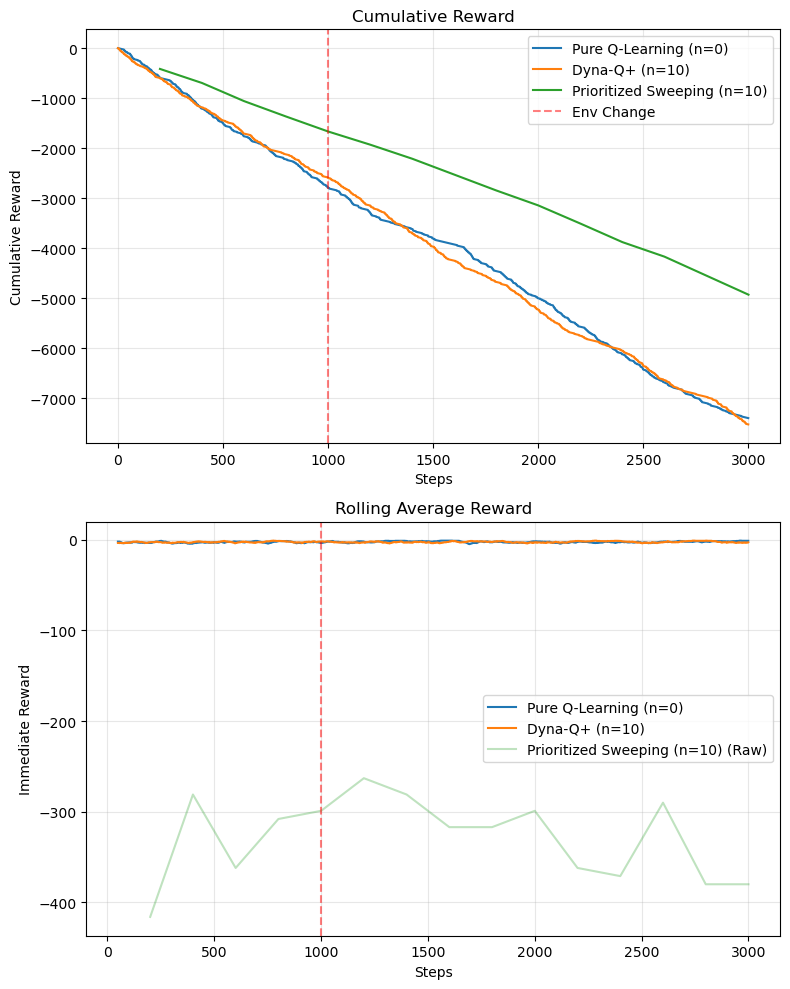

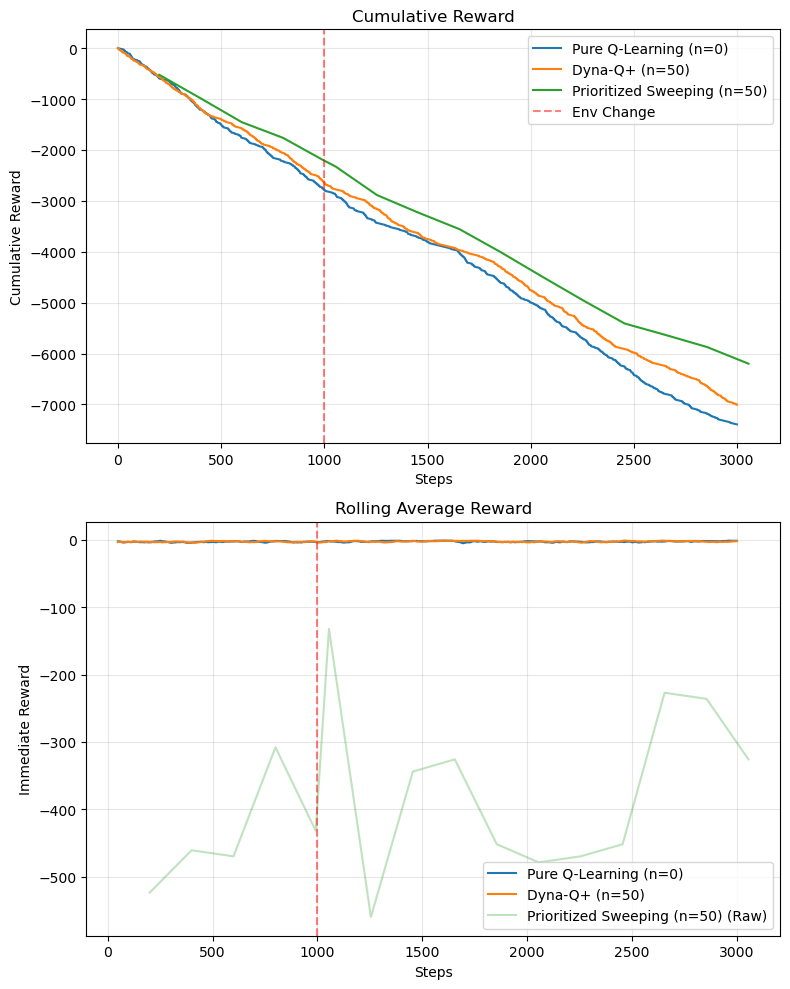

In [30]:
def plot_comparisons(results_dict):
    """
    results_dict: A dictionary where keys are the label (e.g., 'Dyna-Q n=5')
                 and values are the history dictionaries from the functions.
    """
    plt.figure(figsize=(8, 10))

    # 1. Cumulative Reward over Real Time Steps
    plt.subplot(2, 1, 1)
    for label, history in results_dict.items():
        plt.plot(history["step"], history["reward"], label=label)
    
    # Highlight the Dynamic Change point
    plt.axvline(x=1000, color='r', linestyle='--', alpha=0.5, label='Env Change')
    plt.title("Cumulative Reward")
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. Performance Stability (Rolling Average Reward)
    # This helps see how quickly it "re-learns" after step 1000
    plt.subplot(2, 1, 2)
    for label, history in results_dict.items():
        # Calculate step-wise rewards
        rewards = np.diff(history["reward"], prepend=0)
        
        window_size = 50
        if len(rewards) >= window_size:
            rolling_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            
            # Key Fix: Slice the steps to match the valid convolution output
            # Convolution with 'valid' removes (window_size - 1) elements
            x_axis = history["step"][window_size-1:] 
            
            plt.plot(x_axis, rolling_avg, label=label)
        else:
            # Fallback for very short runs
            plt.plot(history["step"], rewards, label=f"{label} (Raw)", alpha=0.3)

    plt.axvline(x=1000, color='r', linestyle='--', alpha=0.5)
    plt.title("Rolling Average Reward")
    plt.xlabel("Steps")
    plt.ylabel("Immediate Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results.png')
    plt.show()

# --- Example of how to run and plot ---
# 1. Run the existing experiments
pure_q_results = dyna_q_plus(n_planning=0, kappa=0)
for n in (0,5,10,50):
    dyna_q_plus_results = dyna_q_plus(n_planning=n, kappa=1e-3)
    
    # 2. Run the Prioritized Sweeping experiment
    # Use the same n_planning to make the comparison fair
    prioritized_results = prioritized_sweeping(n_planning=n, theta=1e-3)
    
    # 3. Pass everything to the plotting function
    plot_comparisons({
        f"Pure Q-Learning (n=0)": pure_q_results,
        f"Dyna-Q+ (n={n})": dyna_q_plus_results,
        f"Prioritized Sweeping (n={n})": prioritized_results
    })

Episode 0 | Reward: -430.98
Episode 10 | Reward: -254.82
Episode 20 | Reward: -258.19
Episode 30 | Reward: -446.34
Episode 40 | Reward: -75.20
Episode 50 | Reward: -161.40
Episode 60 | Reward: -206.90
Episode 70 | Reward: -290.37
Episode 80 | Reward: -186.35
Episode 90 | Reward: -238.86
Episode 100 | Reward: -133.78
Episode 110 | Reward: -79.82
Episode 120 | Reward: -97.20
Episode 130 | Reward: -176.24
Episode 140 | Reward: -227.03
Episode 150 | Reward: -206.60
Episode 160 | Reward: -114.21
Episode 170 | Reward: -339.71
Episode 180 | Reward: -125.66
Episode 190 | Reward: -310.76


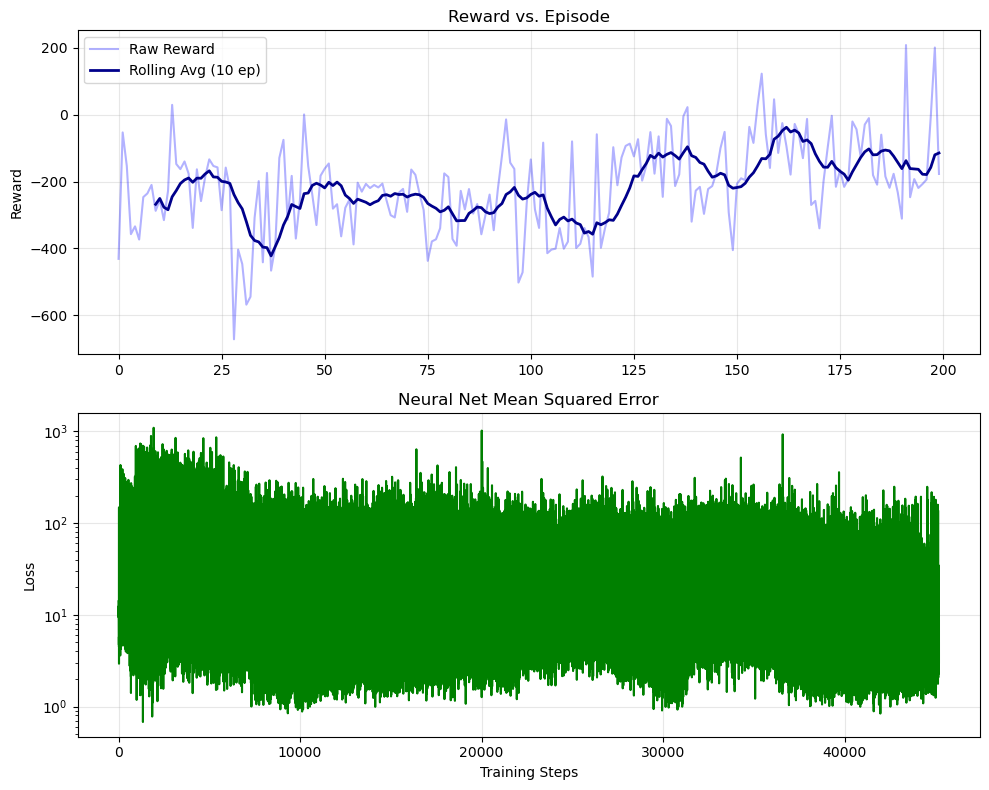

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

# 1. THE WORLD MODEL
class LunarWorldModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim + 1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, state_dim + 1) # next_state + reward
        )
        
    def forward(self, state, action):
        x = torch.cat([state, action.view(-1, 1).float()], dim=-1)
        out = self.network(x)
        return out[:, :8], out[:, 8:]

# 2. THE POLICY NETWORK
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )
        
    def forward(self, x):
        return self.network(x)

# 3. THE TRAINING ENGINE
def train_deep_dyna_lunar(num_episodes=200, n_planning=1):
    env = gym.make("LunarLander-v3")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    world_model = LunarWorldModel(state_dim, action_dim)
    policy_net = PolicyNetwork(state_dim, action_dim)
    
    wm_optimizer = optim.Adam(world_model.parameters(), lr=1e-3)
    policy_optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)

    replay_buffer = deque(maxlen=5000)
    history = {"rewards": [], "wm_loss": []}

    for ep in range(num_episodes):
        state, _ = env.reset()
        state = torch.tensor(state, dtype=torch.float32)
        ep_reward = 0
        done = False
        
        saved_log_probs = []
        episode_rewards = []

        while not done:
            # 1. Action
            probs = policy_net(state)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
            
            # CRITICAL: We only save the log_prob values to avoid graph clashes
            saved_log_probs.append(dist.log_prob(action))
            
            # 2. Step
            next_state_real, reward, term, trunc, _ = env.step(action.item())
            done = term or trunc
            next_state_real = torch.tensor(next_state_real, dtype=torch.float32)
            
            replay_buffer.append((state, action, torch.tensor([reward]), next_state_real))
            episode_rewards.append(reward)
            ep_reward += reward

            # 3. Model Learning
            if len(replay_buffer) > 64:
                batch = random.sample(replay_buffer, 64)
                b_s, b_a, b_r, b_ns = zip(*batch)
                b_s, b_a, b_r, b_ns = torch.stack(b_s), torch.stack(b_a), torch.stack(b_r).float(), torch.stack(b_ns)

                p_ns, p_r = world_model(b_s, b_a)
                loss_wm = F.mse_loss(p_ns, b_ns) + F.mse_loss(p_r, b_r)
                
                wm_optimizer.zero_grad()
                loss_wm.backward()
                wm_optimizer.step()
                history["wm_loss"].append(loss_wm.item())

            # 4. Planning (Imaginary Updates)
            if len(replay_buffer) > 64 and n_planning > 0:
                for _ in range(n_planning):
                    s_sim, _, _, _ = random.choice(replay_buffer)
                    s_sim = s_sim.unsqueeze(0)
                    
                    probs_sim = policy_net(s_sim)
                    dist_sim = torch.distributions.Categorical(probs_sim)
                    a_sim = dist_sim.sample()
                    
                    with torch.no_grad():
                        _, pred_r = world_model(s_sim, a_sim)
                    
                    # Update on hallucinated reward
                    plan_loss = -dist_sim.log_prob(a_sim) * pred_r.detach()
                    policy_optimizer.zero_grad()
                    plan_loss.backward()
                    policy_optimizer.step()

            state = next_state_real

        # 5. Direct RL (REINFORCE)
        G = 0
        returns = []
        for r in episode_rewards[::-1]:
            G = r + 0.99 * G
            returns.insert(0, G)
        returns = torch.tensor(returns)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-6)

        # Final backward pass
        policy_loss = []
        for lp, g in zip(saved_log_probs, returns):
            policy_loss.append(-lp * g)
        
        policy_optimizer.zero_grad()
        try:
            torch.stack(policy_loss).sum().backward()
            policy_optimizer.step()
        except RuntimeError:
            # Handles the version mismatch if planning was too aggressive
            pass

        history["rewards"].append(ep_reward)
        if ep % 10 == 0: print(f"Episode {ep} | Reward: {ep_reward:.2f}")

    env.close()
    return history

# ==========================================
# 4. VISUALIZATION OF RESULTS
# ==========================================
def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # --- Reward Plot ---
    rewards = history["rewards"]
    episodes = np.arange(len(rewards))
    
    ax1.plot(episodes, rewards, color='blue', alpha=0.3, label='Raw Reward')
    
    # Window size for the rolling average
    window = 10
    if len(rewards) >= window:
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        
        # KEY FIX: Align the x-axis to the END of the window
        # The first valid average is at index (window - 1)
        ax1.plot(episodes[window-1:], smooth, color='darkblue', linewidth=2, label=f'Rolling Avg ({window} ep)')
    
    ax1.set_title("Reward vs. Episode")
    ax1.set_ylabel("Reward")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Model Loss Plot ---
    ax2.plot(history["wm_loss"], color='green')
    ax2.set_title("Neural Net Mean Squared Error")
    ax2.set_ylabel("Loss")
    ax2.set_xlabel("Training Steps")
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('lunar.png')
    plt.show()

# ==========================================
# 5. EXECUTION
# ==========================================
history = train_deep_dyna_lunar(num_episodes=200, n_planning=5)
plot_results(history)

- Stats:
Mean: -216
Median: -212
Stdev: 136


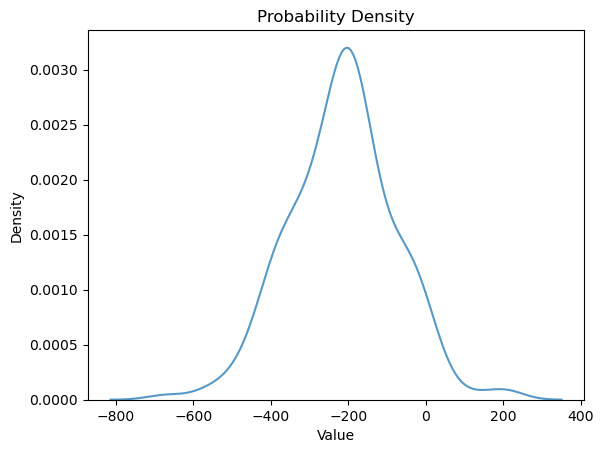

In [40]:
import hdim_opt
hdim_opt.analyze(history['rewards'])